In [1]:
# pandas for data manipulation
# re for regular expressions
import re

# pyplot for plotting
# numpy for numerical operations
import numpy as np
import pandas as pd
from scipy.signal import stft
from sklearn.decomposition import PCA

# other .py files
from utils.csv_import_data_analysis import get_csv_files_generalistic, sort_meta_info

In [2]:
# Retrieve CSV files

path_to: str = "C:\\Users\\pedro\\OneDrive - Universidade de Coimbra\\Ambiente de Trabalho\\tese\\thesis-project"
path: str = path_to + "\\new_data"

FileMap = dict[str, dict[str, str]]
csi_map = dict[str, dict[str, dict[str, np.ndarray]]]


data_files = get_csv_files_generalistic(path)
scenarios_id, users_id, activities_id, esps_id = sort_meta_info(path)
print(f"Scenarios: {scenarios_id}")
print(f"Users: {users_id}")
print(f"Activities: {activities_id}")
print(f"ESPs: {esps_id}")
print("\nData files: ", data_files)

Scenarios: ['00', '01']
Users: ['00', '01']
Activities: ['11']
ESPs: ['02', '03']

Data files:  {'scenario_11': {'user_00': {'activity_00': {'esp_02': [WindowsPath('C:/Users/pedro/OneDrive - Universidade de Coimbra/Ambiente de Trabalho/tese/thesis-project/new_data/11_00_00_02_2026-02-25.csv')], 'esp_03': [WindowsPath('C:/Users/pedro/OneDrive - Universidade de Coimbra/Ambiente de Trabalho/tese/thesis-project/new_data/11_00_00_03_2026-02-25.csv')]}}, 'user_01': {'activity_01': {'esp_02': [WindowsPath('C:/Users/pedro/OneDrive - Universidade de Coimbra/Ambiente de Trabalho/tese/thesis-project/new_data/11_01_01_02_2026-02-25.csv')], 'esp_03': [WindowsPath('C:/Users/pedro/OneDrive - Universidade de Coimbra/Ambiente de Trabalho/tese/thesis-project/new_data/11_01_01_03_2026-02-25.csv')]}}}}


In [3]:
# Per-packet normalization to mitigate AGC effects.
# magnitude shape: (n_samples, n_subcarriers)

# antes de sacar o AGC (5 GHz)
def calibrate_magnitude(magnitude: np.ndarray) -> np.ndarray:
	norm = np.linalg.norm(magnitude, axis=1, keepdims=True)
	norm[norm == 0] = 1  # avoid division by zero
	return magnitude / norm


def apply_pca(magnitude_data, variance_ratio=0.999):
	pca = PCA(n_components=variance_ratio)
	transformed = pca.fit_transform(magnitude_data)
	return transformed, pca


def process_csi(data_file: str) -> np.ndarray:

	file_csv = pd.read_csv(data_file, header=None)

	# number of samples
	csi_raw: pd.Series = file_csv.iloc[:, 25]

	total_sc: int = 128
	valid_csi: list[list[float]] = []

	# contar CSI inválidos
	no_match_count: int = 0
	no_complete_count: int = 0

	for entry in csi_raw:
		match = re.search(r"\[(.*?)\]", str(entry))
		if not match:
			no_match_count += 1
			continue

		nums = [float(n) for n in re.findall(r"-?\d+", match.group(1))]

		if len(nums) == total_sc:
			valid_csi.append(nums)
		else:
			no_complete_count += 1

	valid_csi = np.array(valid_csi)

	# (n_amostras, 128)
	complex_csi = valid_csi[:, ::2] + 1j * valid_csi[:, 1::2]

	# coloca sc DC no centro (index 32)
	fft_csi = np.fft.fftshift(complex_csi, axes=1)

	# Extract the 52 active subcarriers (IEEE 802.11n standard): [6:58]
	# (n_amostras, 52)
	active_sc = fft_csi[:, 6:58]

	# Remove subcarriers at positions 25, 26, 27 (center)
	# (n_amostras, 49)
	active_sc = np.delete(active_sc, [25, 26, 27], axis=1)

	# seleciona sub_carriers: 2 a 47
	active_sc = active_sc[:, 2:48]

	return np.abs(active_sc)


def process_magnitude(data_files: FileMap) -> csi_map:

	magnitudes = {}

	for scenario_key, users_map in data_files.items():
		magnitudes[scenario_key] = {}

		for user_key, activities_map in users_map.items():
			magnitudes[scenario_key][user_key] = {}

			for activity, esps_map in activities_map.items():
				magnitudes[scenario_key][user_key][activity] = {}

				for esp, file_path in esps_map.items():
					if file_path is not None:
						path = file_path[0] if isinstance(file_path, list) else file_path
						magnitudes[scenario_key][user_key][activity][esp] = process_csi(str(path))

	return magnitudes

In [4]:
def compute_pca1_variance(pca_features: np.ndarray) -> float:
	pca1 = pca_features[:, 0]
	return np.var(pca1)


def compute_doppler_energy(pca_features: np.ndarray, fs: float = 1000.0):
	pca1 = pca_features[:, 0]

	# Remove mean (remove static component)
	pca1 = pca1 - np.mean(pca1)

	f, t, Zxx = stft(pca1, fs=fs, nperseg=256)

	# Remove DC component (f=0)
	non_zero_idx = f > 0.1

	energy = np.sum(np.abs(Zxx[non_zero_idx, :])**2)

	return energy


def compute_snr_proxy(pca_features: np.ndarray, fs: float = 1000.0):
	pca1 = pca_features[:, 0]
	pca1 = pca1 - np.mean(pca1)

	f, t, Zxx = stft(pca1, fs=fs, nperseg=256)

	power_spectrum = np.abs(Zxx)**2

	# Static band (near DC)
	static_idx = f < 0.1

	# Dynamic band
	dynamic_idx = (f >= 0.1) & (f <= 10)

	static_power = np.sum(power_spectrum[static_idx, :])
	dynamic_power = np.sum(power_spectrum[dynamic_idx, :])

	if static_power == 0:
		return 0

	return dynamic_power / static_power

In [5]:
magnitude_data = process_magnitude(data_files)

In [6]:
# define sampling frequency (Hz) as
# the original packet rate/s
fs = 1000

# Compute metrics for each individual CSI file
metrics_per_file = {}

scenarios = {
	"11": "Cenário 1 - 2.4 GHz",
	"12": "Cenário 1 - 5 GHz",
	"21": "Cenário 2 - 2.4 GHz",
	"22": "Cenário 2 - 5 GHz",
}

for user_key, activities_map in magnitude_data.items():
	for activity, places_map in activities_map.items():
		for place, esps_map in places_map.items():
			for esp, features in esps_map.items():
				label = f"{user_key}-{activity}-{place}-{esp}"
				metrics_per_file[label] = {
					"PCA1 Variance": compute_pca1_variance(features),
					"Doppler Energy": compute_doppler_energy(features, fs),
					"SNR Proxy": compute_snr_proxy(features, fs),
				}

print(f"Computed metrics for {len(metrics_per_file)} files")


Computed metrics for 4 files


c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\signal\_spectral_py.py:1595: UserWarning: nperseg = 256 is greater than input length  = 139, using nperseg = 139
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,
c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\signal\_spectral_py.py:1595: UserWarning: nperseg = 256 is greater than input length  = 161, using nperseg = 161
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,


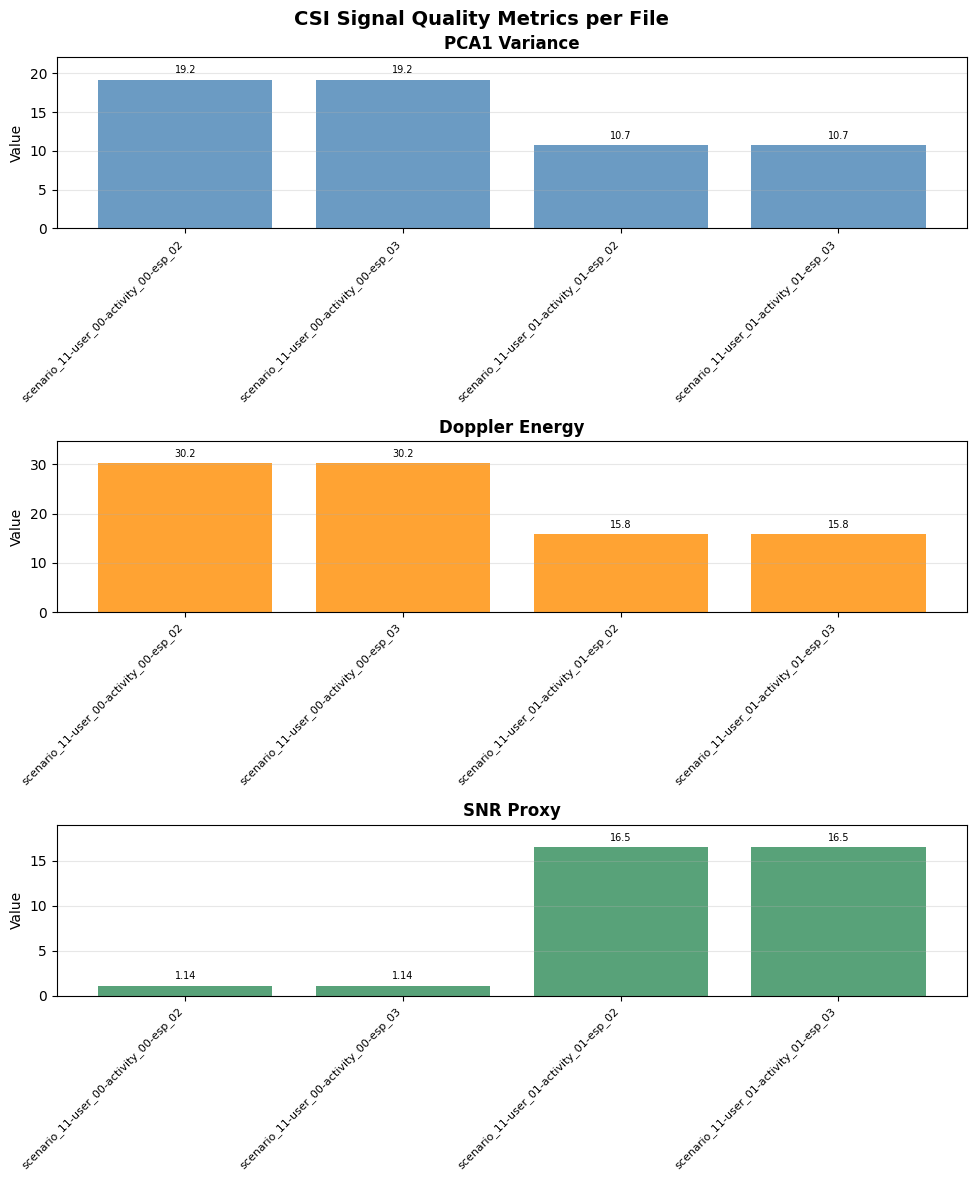

In [7]:
metric_names = ["PCA1 Variance", "Doppler Energy", "SNR Proxy"]
colors = ["steelblue", "darkorange", "seagreen"]
labels = list(metrics_per_file.keys())
x = np.arange(len(labels))

from matplotlib import pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(max(10, len(labels) * 0.8), 12))

for ax, metric, color in zip(axes, metric_names, colors):
	values = [metrics_per_file[lbl][metric] for lbl in labels]
	bars = ax.bar(x, values, color=color, alpha=0.8)
	ax.bar_label(bars, fmt="%.3g", padding=3, fontsize=7)
	ax.set_title(metric, fontsize=12, fontweight="bold")
	ax.set_ylabel("Value")
	ax.set_xticks(x)
	ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
	ax.grid(axis="y", alpha=0.3)
	ax.margins(y=0.15)

fig.suptitle("CSI Signal Quality Metrics per File", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


#### CSI Magnitude vs Number of Packages analysis

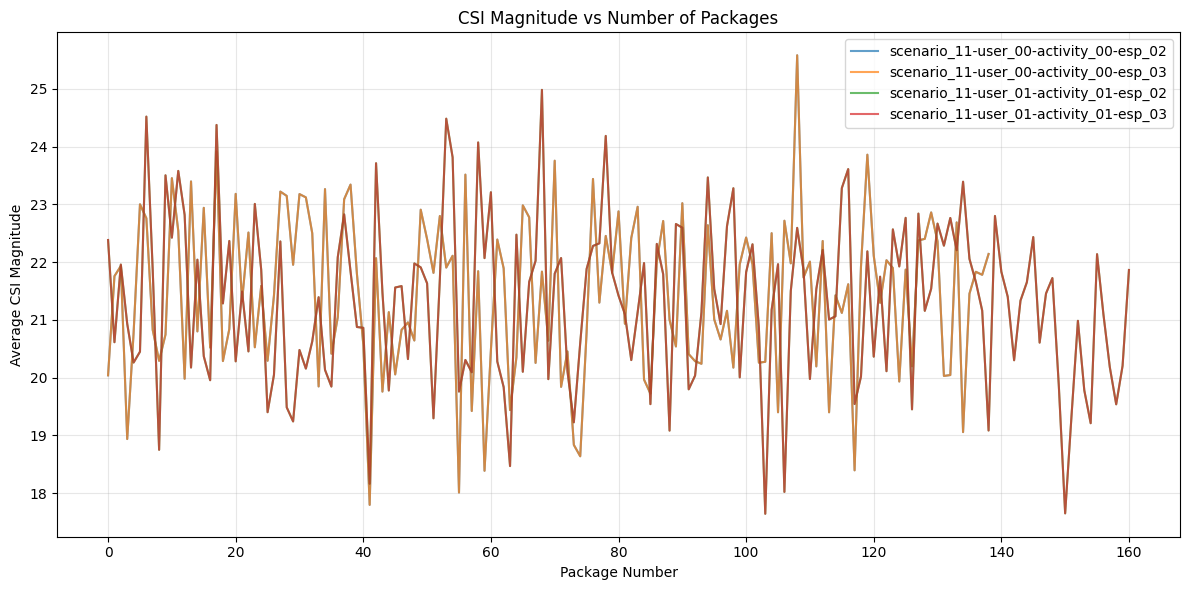

In [8]:
plt.figure(figsize=(12, 6))

for user_key, activities_map in magnitude_data.items():
	for activity, places_map in activities_map.items():
		for place, esps_map in places_map.items():
			for esp, csi_magnitude in esps_map.items():
				# Calculate average magnitude across all subcarriers for each packet
				avg_magnitude = csi_magnitude.mean(axis=1)
				n_packets = len(avg_magnitude)

				plt.plot(range(n_packets), avg_magnitude, label=f'{user_key}-{activity}-{place}-{esp}', alpha=0.7)

plt.xlabel('Package Number')
plt.ylabel('Average CSI Magnitude')
plt.title('CSI Magnitude vs Number of Packages')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Dataset

In [9]:
# função retirada do pipeline da Diana
def segment_signal(
	signal: np.ndarray, window_size: int, overlap: int,
) -> list[np.ndarray]:
	segments: list[np.ndarray] = []

	for i in range(0, signal.shape[0], overlap):
		if i + window_size < signal.shape[0]:
			segment = signal[i : i + window_size]
			segments.append(segment)

	return segments


def process_pipeline(csi_magnitude: np.ndarray) -> np.ndarray:

	print("Original CSI magnitude shape:", csi_magnitude.shape)
	csi_magnitude = calibrate_magnitude(csi_magnitude)

	print("Calibrated CSI magnitude shape:", csi_magnitude.shape)
	pca_features, _ = apply_pca(csi_magnitude, variance_ratio=0.999)

	# parâmetros de segmentação
	window_size: int = 10
	overlap_size: int = 2

	print("PCA features shape:", pca_features.shape)

	segmented_data = segment_signal(pca_features, window_size, overlap_size)
	segmented_data = np.array(segmented_data)

	print("segmented data shape:", segmented_data.shape)

	# obtemos 3 matrizes de features: mean e std
	features = [
		np.var(segmented_data[:, :, 0], axis=1),
		np.std(segmented_data[:, :, 0], axis=1),
		np.sum(segmented_data[:, :, 0] ** 2, axis=1),
	]
	features = np.array(features)

	print("features shape (3, n_segments):", features.shape)

	df_x = np.transpose(features)

	print("features transposed shape:", df_x.shape, "\n")

	return df_x


def build_scenario_dataset(
	users_map: dict[str, dict[str, dict[str, np.ndarray]]],
	scenario_key: str,
	expected_users: int = 2,
	expected_activities: int = 2,
	expected_esps: int = 3,
) -> pd.DataFrame:
	rows: list[dict[str, object]] = []

	for user_key, activities_map in users_map.items():
		for activity_key, esps_map in activities_map.items():
			for esp_key, csi in esps_map.items():
				window_features = process_pipeline(csi)

				for feature_vector in window_features:
					rows.append(
						{
							"scenario": scenario_key,
							"user": user_key,
							"activity": activity_key,
							"esp": esp_key,
							"variance": feature_vector[0],
							"std": feature_vector[1],
							"energy": feature_vector[2],
						},
					)

	scenario_df = pd.DataFrame(rows)

	users_found = scenario_df["user"].nunique() if not scenario_df.empty else 0
	activities_found = scenario_df["activity"].nunique() if not scenario_df.empty else 0
	esps_found = scenario_df["esp"].nunique() if not scenario_df.empty else 0

	if users_found != expected_users or activities_found != expected_activities or esps_found != expected_esps:
		print(
			f"[WARN] Scenario {scenario_key}: users={users_found}/{expected_users}, "
			f"activities={activities_found}/{expected_activities}, esps={esps_found}/{expected_esps}",
		)

	# Add label column: activity "00" -> 0, activity "01" -> 1
	activity_to_label = {
		"activity_00": 0,
		"activity_01": 1,
	}
	scenario_df["label"] = scenario_df["activity"].map(activity_to_label)

	# Keep only feature columns and label
	scenario_df = scenario_df[["variance", "std", "energy", "label"]]

	return scenario_df

In [10]:
# Dataset per scenario
dataset_per_scenario: dict[str, pd.DataFrame] = {}

for scenario_key, users_map in magnitude_data.items():
	print(f"Building dataset for scenario {scenario_key}\n")
	scenario_df = build_scenario_dataset(users_map, scenario_key)
	dataset_per_scenario[scenario_key] = scenario_df
	print(f"Scenario {scenario_key}: {scenario_df.shape[0]} windows (features + labels)")

scenario_keys = sorted(dataset_per_scenario.keys())

if len(scenario_keys) != 4:
	print(f"\n[WARN] Expected 4 scenarios, found {len(scenario_keys)}: {scenario_keys}")

# Create explicit variables for up to 4 scenarios found in the data
dataset_1 = dataset_per_scenario[scenario_keys[0]] if len(scenario_keys) > 0 else pd.DataFrame()
dataset_2 = dataset_per_scenario[scenario_keys[1]] if len(scenario_keys) > 1 else pd.DataFrame()
dataset_3 = dataset_per_scenario[scenario_keys[2]] if len(scenario_keys) > 2 else pd.DataFrame()
dataset_4 = dataset_per_scenario[scenario_keys[3]] if len(scenario_keys) > 3 else pd.DataFrame()

print("\nCreated scenario datasets:")
for i, key in enumerate(scenario_keys[:4], start=1):
	print(f"- dataset_{i} -> scenario '{key}'")

Building dataset for scenario scenario_11

Original CSI magnitude shape: (139, 46)
Calibrated CSI magnitude shape: (139, 46)
PCA features shape: (139, 24)
segmented data shape: (65, 10, 24)
features shape (3, n_segments): (3, 65)
features transposed shape: (65, 3) 

Original CSI magnitude shape: (139, 46)
Calibrated CSI magnitude shape: (139, 46)
PCA features shape: (139, 24)
segmented data shape: (65, 10, 24)
features shape (3, n_segments): (3, 65)
features transposed shape: (65, 3) 

Original CSI magnitude shape: (161, 46)
Calibrated CSI magnitude shape: (161, 46)
PCA features shape: (161, 30)
segmented data shape: (76, 10, 30)
features shape (3, n_segments): (3, 76)
features transposed shape: (76, 3) 

Original CSI magnitude shape: (161, 46)
Calibrated CSI magnitude shape: (161, 46)
PCA features shape: (161, 30)
segmented data shape: (76, 10, 30)
features shape (3, n_segments): (3, 76)
features transposed shape: (76, 3) 

[WARN] Scenario scenario_11: users=2/2, activities=2/2, esps=

In [13]:
dataset_per_scenario['scenario_11']

,variance,std,energy,label
0,0.054505,0.233462,0.607879,0
1,0.043553,0.208693,0.467533,0
2,0.045750,0.213892,0.457650,0
3,0.030924,0.175854,0.372347,0
4,0.019916,0.141126,0.383072,0
...,...,...,...,...
277,0.028137,0.167741,0.291652,1
278,0.028044,0.167464,0.290373,1
279,0.041373,0.203403,0.416706,1
280,0.035599,0.188677,0.361109,1


In [ ]:
print("Dataset structure (first 5 rows):")
print(dataset_1.head())
print(f"\nDataset shape: {dataset_1.shape}")
print(f"Columns: {dataset_1.columns.tolist()}")
print(f"Label values: {dataset_1['label'].unique()}")